# Credit Card Loan Recommendation Classification

Borrowers often use personal loans to consolidate high-interest credit card balances into a structured installment loan. In that setting, a lender needs a simple first-pass screening approach to separate applications that should move forward for consideration from applications that should be held back for closer review.

This notebook studies that screening problem using public LendingClub data. Because the dataset does not contain an explicit historical recommendation field, the project defines a proxy target from resolved outcomes:
- `consider`: loans that were fully paid
- `hold`: loans that ended in default-like outcomes


## Problem Statement

When a borrower applies for a loan with the purpose `credit_card`, can origination-time borrower and loan attributes be used to support an initial recommendation of `consider` or `hold`?

The business goal is not fully automated approval. The goal is a clear, data-driven screening model that can help prioritize which credit-card debt-consolidation cases deserve further attention.


## Data Source and Scope

Dataset used:
- LendingClub accepted loans dataset from Kaggle
- Dataset page: [Kaggle: Lending Club](https://www.kaggle.com/datasets/wordsforthewise/lending-club)
- File used in this notebook: `accepted_2007_to_2018Q4.csv.gz`

Why this dataset is appropriate:
- it is a large public consumer-lending dataset
- it includes origination-time borrower and loan attributes
- it includes final loan outcomes needed to construct the proxy target

Scope used in this notebook:
- only accepted loans
- only `purpose == "credit_card"`
- only resolved loan statuses

Resolved statuses retained:
- `Fully Paid`
- `Charged Off`
- `Default`
- `Does not meet the credit policy. Status:Charged Off`

Target definition:
- `consider` for `Fully Paid`
- `hold` for default-like outcomes

Unit of analysis:
- each row represents one accepted LendingClub loan


## 1) Imports and Paths

In [1]:
from pathlib import Path
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)

NOTEBOOK_DIR = Path.cwd().resolve()
REPO_ROOT = NOTEBOOK_DIR if (NOTEBOOK_DIR / "data").exists() else NOTEBOOK_DIR.parent
REPORT_DIR = REPO_ROOT / "reports"
FIG_DIR = REPORT_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

DATA_FILE = REPO_ROOT / "data" / "raw" / "lending_club" / "accepted_2007_to_2018Q4.csv.gz"
ALT_DATA_FILE = REPO_ROOT / "data" / "raw" / "lending_club" / "accepted_2007_to_2018q4.csv" / "accepted_2007_to_2018Q4.csv"
if not DATA_FILE.exists() and ALT_DATA_FILE.exists():
    DATA_FILE = ALT_DATA_FILE
if not DATA_FILE.exists():
    fallback_file = REPO_ROOT.parent / "loan-refinance-intelligence" / "data" / "raw" / "lending_club" / "accepted_2007_to_2018Q4.csv.gz"
    if fallback_file.exists():
        DATA_FILE = fallback_file

MAX_MODEL_ROWS = int(os.getenv("PROJECT_MAX_ROWS", "30000"))
RANDOM_STATE = 42

print(f"Dataset file name: {DATA_FILE.name if DATA_FILE.exists() else 'missing'}")
print(f"Dataset available: {DATA_FILE.exists()}")
print(f"Maximum modeling sample size: {MAX_MODEL_ROWS}")


Dataset file name: accepted_2007_to_2018Q4.csv.gz
Dataset available: True
Maximum modeling sample size: 30000


## 2) Load and Filter LendingClub Data

In [2]:
if not DATA_FILE.exists():
    raise FileNotFoundError("Place the LendingClub accepted loans file under data/raw/lending_club/ before running this notebook.")

resolved_statuses = {
    "Fully Paid",
    "Charged Off",
    "Default",
    "Does not meet the credit policy. Status:Charged Off",
}

selected_columns = [
    "id",
    "loan_status",
    "purpose",
    "term",
    "int_rate",
    "installment",
    "grade",
    "sub_grade",
    "annual_inc",
    "dti",
    "revol_util",
    "fico_range_low",
    "fico_range_high",
    "delinq_2yrs",
    "open_acc",
]

header = pd.read_csv(DATA_FILE, nrows=0, low_memory=False)
usecols = [c for c in selected_columns if c in header.columns]

chunks = []
for chunk in pd.read_csv(DATA_FILE, usecols=usecols, chunksize=250000, low_memory=False):
    mask = chunk["purpose"].eq("credit_card") & chunk["loan_status"].isin(resolved_statuses)
    filtered = chunk.loc[mask].copy()
    if not filtered.empty:
        chunks.append(filtered)

df = pd.concat(chunks, ignore_index=True)
print(f"Filtered rows before dedupe/sample: {len(df):,}")
display(df.head())


Filtered rows before dedupe/sample: 295,354


,id,term,int_rate,installment,grade,sub_grade,annual_inc,loan_status,purpose,dti,delinq_2yrs,fico_range_low,fico_range_high,open_acc,revol_util
0,68466926,36 months,6.49,306.45,A,A2,85000.0,Fully Paid,credit_card,13.07,0.0,685.0,689.0,14.0,34.5
1,68616873,36 months,11.48,263.74,B,B5,42000.0,Fully Paid,credit_card,34.80,0.0,700.0,704.0,8.0,39.1
2,68354783,36 months,7.49,298.58,A,A4,60000.0,Fully Paid,credit_card,22.44,0.0,695.0,699.0,7.0,59.4
3,68009401,60 months,14.85,379.39,C,C5,48000.0,Fully Paid,credit_card,33.18,0.0,685.0,689.0,11.0,29.6
4,68436666,36 months,13.44,169.54,C,C3,79000.0,Fully Paid,credit_card,12.70,0.0,665.0,669.0,3.0,101.5


## 3) Data Cleaning and Feature Engineering

In [3]:
def to_numeric_percent(series: pd.Series) -> pd.Series:
    cleaned = series.astype(str).str.replace("%", "", regex=False).str.strip()
    return pd.to_numeric(cleaned, errors="coerce")

df["recommendation_label"] = np.where(df["loan_status"].eq("Fully Paid"), "consider", "hold")
df["int_rate_num"] = to_numeric_percent(df["int_rate"])
df["revol_util_num"] = to_numeric_percent(df["revol_util"])
df["fico_avg"] = (
    pd.to_numeric(df["fico_range_low"], errors="coerce")
    + pd.to_numeric(df["fico_range_high"], errors="coerce")
) / 2.0
df["term_months"] = pd.to_numeric(df["term"].astype(str).str.extract(r"(\d+)")[0], errors="coerce")
df["annual_inc_log1p"] = np.log1p(pd.to_numeric(df["annual_inc"], errors="coerce").clip(lower=0))
monthly_income = (pd.to_numeric(df["annual_inc"], errors="coerce") / 12.0).clip(lower=1.0)
df["installment_to_monthly_income"] = pd.to_numeric(df["installment"], errors="coerce") / monthly_income

duplicate_rows = int(df["id"].duplicated().sum()) if "id" in df.columns else int(df.duplicated().sum())
if "id" in df.columns:
    df = df.drop_duplicates(subset=["id"], keep="first")
else:
    df = df.drop_duplicates(keep="first")

if len(df) > MAX_MODEL_ROWS:
    df = df.sample(n=MAX_MODEL_ROWS, random_state=RANDOM_STATE)

df = df.reset_index(drop=True)
print(f"Rows after dedupe/sample: {len(df):,}")
print(f"Duplicate rows removed: {duplicate_rows:,}")
display(df.head())


Rows after dedupe/sample: 30,000
Duplicate rows removed: 0


,id,term,int_rate,installment,grade,sub_grade,annual_inc,loan_status,purpose,dti,delinq_2yrs,fico_range_low,fico_range_high,open_acc,revol_util,recommendation_label,int_rate_num,revol_util_num,fico_avg,term_months,annual_inc_log1p,installment_to_monthly_income
0,75221661,36 months,11.99,478.22,C,C1,59000.0,Fully Paid,credit_card,17.98,0.0,670.0,674.0,7.0,10.7,consider,11.99,10.7,672.0,36,10.985310,0.097265
1,1487483,36 months,14.09,747.74,B,B5,55000.0,Fully Paid,credit_card,21.86,0.0,695.0,699.0,5.0,70.9,consider,14.09,70.9,697.0,36,10.915107,0.163143
2,55451272,36 months,11.53,148.46,B,B5,19000.0,Fully Paid,credit_card,25.90,0.0,665.0,669.0,5.0,87.1,consider,11.53,87.1,667.0,36,9.852247,0.093764
3,7956313,36 months,20.20,745.32,D,D5,80000.0,Fully Paid,credit_card,17.88,0.0,670.0,674.0,13.0,64.0,consider,20.20,64.0,672.0,36,11.289794,0.111798
4,134914565,36 months,6.19,884.74,A,A2,62000.0,Fully Paid,credit_card,27.33,0.0,735.0,739.0,19.0,31.7,consider,6.19,31.7,737.0,36,11.034906,0.171240


## 4) Missingness and Outlier Checks

This section documents the main data-quality steps used before modeling:
- inspect missing values
- impute numeric columns with the median and categorical columns with the mode
- summarize potential outliers with the IQR rule


In [4]:
model_df = df.copy()

numeric_features = [
    "int_rate_num",
    "annual_inc",
    "annual_inc_log1p",
    "dti",
    "revol_util_num",
    "installment",
    "fico_avg",
    "delinq_2yrs",
    "open_acc",
    "term_months",
    "installment_to_monthly_income",
]
categorical_features = ["grade", "sub_grade"]

missing_before = (
    model_df[numeric_features + categorical_features]
    .isna()
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
    .rename("missing_pct_before")
    .rename_axis("feature").reset_index()
)

for col in numeric_features:
    model_df[col] = pd.to_numeric(model_df[col], errors="coerce")
    model_df[col] = model_df[col].fillna(model_df[col].median())

for col in categorical_features:
    mode = model_df[col].mode(dropna=True)
    model_df[col] = model_df[col].fillna(mode.iloc[0] if not mode.empty else "unknown")

missing_after = (
    model_df[numeric_features + categorical_features]
    .isna()
    .mean()
    .mul(100)
    .round(2)
    .rename("missing_pct_after")
    .rename_axis("feature").reset_index()
)

missing_summary = missing_before.merge(missing_after, on="feature")
display(missing_summary)

outlier_rows = []
for col in ["annual_inc", "dti", "revol_util_num", "installment", "fico_avg"]:
    series = pd.to_numeric(model_df[col], errors="coerce").dropna()
    q1 = float(series.quantile(0.25))
    q3 = float(series.quantile(0.75))
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    mask = (series < lower) | (series > upper)
    outlier_rows.append(
        {
            "feature": col,
            "q1": round(q1, 2),
            "q3": round(q3, 2),
            "iqr": round(iqr, 2),
            "outlier_pct": round(float(mask.mean() * 100), 2),
        }
    )

outlier_summary = pd.DataFrame(outlier_rows).sort_values("outlier_pct", ascending=False)
display(outlier_summary)


,feature,missing_pct_before,missing_pct_after
0,dti,0.02,0.0
1,revol_util_num,0.02,0.0
2,int_rate_num,0.00,0.0
3,annual_inc,0.00,0.0
4,annual_inc_log1p,0.00,0.0
5,installment,0.00,0.0
6,fico_avg,0.00,0.0
7,delinq_2yrs,0.00,0.0
8,open_acc,0.00,0.0
9,term_months,0.00,0.0


,feature,q1,q3,iqr,outlier_pct
0,annual_inc,45760.00,92000.00,46240.00,4.43
3,installment,263.61,585.74,322.13,3.09
4,fico_avg,672.00,712.00,40.00,2.28
1,dti,12.13,24.06,11.93,0.34
2,revol_util_num,39.00,73.43,34.43,0.01


## 5) Exploratory Data Analysis

,recommendation_label,count,pct
0,consider,25006,83.35
1,hold,4994,16.65


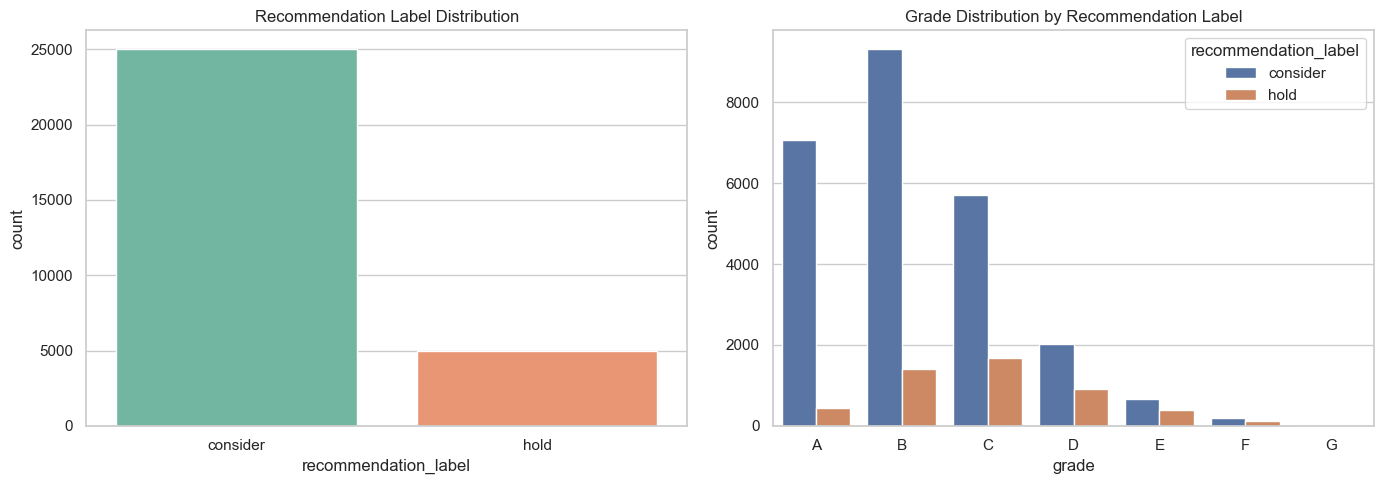

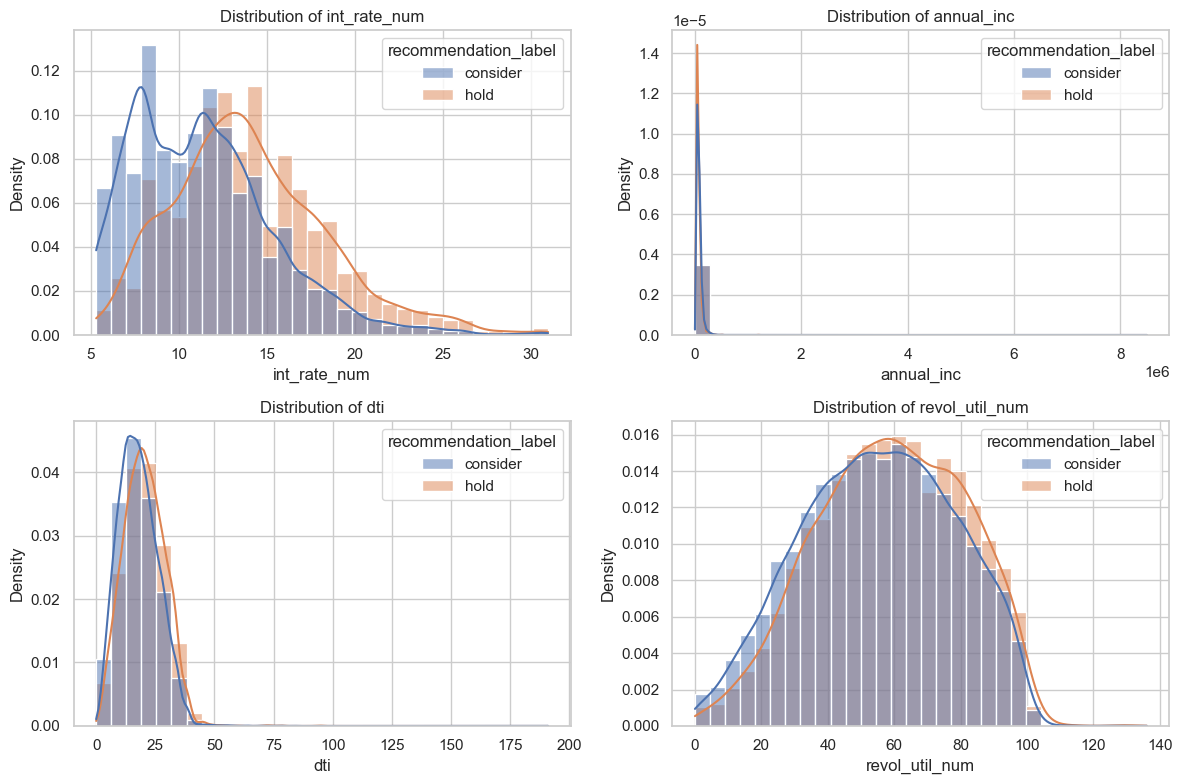

In [5]:
label_summary = (
    model_df["recommendation_label"].value_counts()
    .rename_axis("recommendation_label")
    .reset_index(name="count")
)
label_summary["pct"] = (label_summary["count"] / len(model_df) * 100).round(2)
display(label_summary)
label_summary.to_csv(REPORT_DIR / "label_summary.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(data=model_df, x="recommendation_label", order=["consider", "hold"], ax=axes[0], palette="Set2", hue="recommendation_label", legend=False)
axes[0].set_title("Recommendation Label Distribution")
axes[0].set_xlabel("recommendation_label")

grade_plot = model_df.groupby(["grade", "recommendation_label"]).size().reset_index(name="count")
sns.barplot(data=grade_plot, x="grade", y="count", hue="recommendation_label", ax=axes[1])
axes[1].set_title("Grade Distribution by Recommendation Label")
axes[1].set_xlabel("grade")
plt.tight_layout()
plt.savefig(FIG_DIR / "class_balance_and_grade_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

plot_cols = ["int_rate_num", "annual_inc", "dti", "revol_util_num"]
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
for ax, col in zip(axes, plot_cols):
    sns.histplot(data=model_df, x=col, hue="recommendation_label", bins=30, kde=True, ax=ax, stat="density", common_norm=False)
    ax.set_title(f"Distribution of {col}")
plt.tight_layout()
plt.savefig(FIG_DIR / "feature_distributions.png", dpi=150, bbox_inches="tight")
plt.show()


## 6) Train/Test Split and Modeling

Selected features:
- Numeric: `int_rate_num`, `annual_inc`, `annual_inc_log1p`, `dti`, `revol_util_num`, `installment`, `fico_avg`, `delinq_2yrs`, `open_acc`, `term_months`, `installment_to_monthly_income`
- Categorical: `grade`, `sub_grade`

Models compared:
- Logistic Regression as the baseline classifier
- Random Forest as a nonlinear comparison model


,model,roc_auc,pr_auc,precision,recall,f1
0,logistic_regression,0.7081,0.9172,0.9071,0.6365,0.7481
1,random_forest,0.7013,0.9144,0.8338,1.0000,0.9094


,feature,coefficient,abs_coefficient
11,cat__grade_A,1.805834,1.805834
17,cat__grade_G,-1.695794,1.695794
16,cat__grade_F,-1.001503,1.001503
12,cat__grade_B,0.908568,0.908568
52,cat__sub_grade_G5,-0.899273,0.899273
18,cat__sub_grade_A1,0.819397,0.819397
19,cat__sub_grade_A2,0.757589,0.757589
15,cat__grade_E,-0.648545,0.648545
47,cat__sub_grade_F5,-0.637875,0.637875
23,cat__sub_grade_B1,0.588596,0.588596


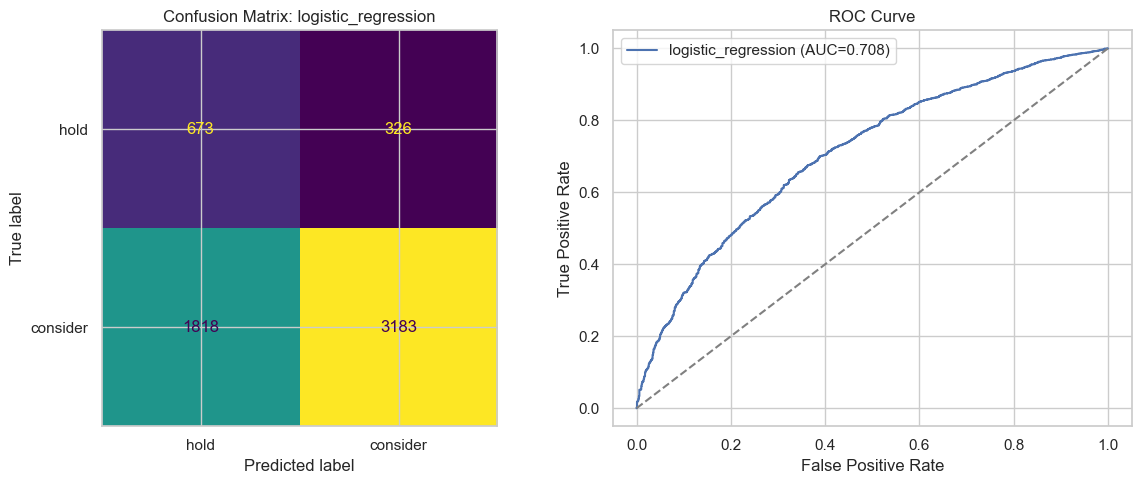

Selected comparison winner by ROC-AUC: logistic_regression


In [6]:
X = model_df[numeric_features + categorical_features].copy()
y = (model_df["recommendation_label"] == "consider").astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]),
            numeric_features,
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore")),
            ]),
            categorical_features,
        ),
    ]
)

models = {
    "logistic_regression": Pipeline([
        ("prep", preprocessor),
        ("model", LogisticRegression(max_iter=2000, class_weight="balanced", solver="liblinear")),
    ]),
    "random_forest": Pipeline([
        ("prep", preprocessor),
        ("model", RandomForestClassifier(n_estimators=300, max_depth=10, min_samples_leaf=20, random_state=RANDOM_STATE)),
    ]),
}

rows = []
fitted_models = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    fitted_models[name] = model
    proba = model.predict_proba(X_test)[:, 1]
    pred = (proba >= 0.5).astype(int)
    rows.append(
        {
            "model": name,
            "roc_auc": round(roc_auc_score(y_test, proba), 4),
            "pr_auc": round(average_precision_score(y_test, proba), 4),
            "precision": round(precision_score(y_test, pred), 4),
            "recall": round(recall_score(y_test, pred), 4),
            "f1": round(f1_score(y_test, pred), 4),
        }
    )

results_df = pd.DataFrame(rows).sort_values(["roc_auc", "f1"], ascending=False)
display(results_df)
results_df.to_csv(REPORT_DIR / "model_results.csv", index=False)

logistic_model = fitted_models["logistic_regression"]
logistic_feature_names = logistic_model.named_steps["prep"].get_feature_names_out()
logistic_coefficients = logistic_model.named_steps["model"].coef_[0]
coefficient_summary = pd.DataFrame({
    "feature": logistic_feature_names,
    "coefficient": logistic_coefficients,
})
coefficient_summary["abs_coefficient"] = coefficient_summary["coefficient"].abs()
coefficient_summary = coefficient_summary.sort_values("abs_coefficient", ascending=False)
display(coefficient_summary.head(10))
coefficient_summary.to_csv(REPORT_DIR / "logistic_coefficients.csv", index=False)

best_model_name = results_df.iloc[0]["model"]
best_model = fitted_models[best_model_name]
best_proba = best_model.predict_proba(X_test)[:, 1]
best_pred = (best_proba >= 0.5).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(confusion_matrix(y_test, best_pred), display_labels=["hold", "consider"]).plot(ax=axes[0], colorbar=False)
axes[0].set_title(f"Confusion Matrix: {best_model_name}")

fpr, tpr, _ = roc_curve(y_test, best_proba)
axes[1].plot(fpr, tpr, label=f"{best_model_name} (AUC={roc_auc_score(y_test, best_proba):.3f})")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[1].set_title("ROC Curve")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "model_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Selected comparison winner by ROC-AUC: {best_model_name}")


## 7) Results and Interpretation

Metric choice:
- `ROC-AUC` is the primary comparison metric because it measures ranking quality across all classification thresholds.
- `precision` shows how often predicted `consider` cases are correct.
- `recall` shows how many actual `consider` cases are captured.
- `F1` summarizes the precision-recall tradeoff in a single number.

How to interpret the comparison:
- Logistic Regression is the baseline because it is simple, transparent, and easy to explain.
- Random Forest is included to test whether nonlinear relationships improve predictive performance.
- The Logistic Regression coefficient table helps identify which features push the prediction toward `consider` or `hold`.

Business relevance:
- A stronger screening model can help prioritize which applications should move forward for further review.
- This project should be interpreted as decision support for triage, not as a replacement for full underwriting.


## 8) Limitations and Next Steps

Limitations:
- `consider` / `hold` is a proxy target derived from observed loan outcome, not a directly observed historical recommendation.
- The dataset is limited to public LendingClub data and one loan-purpose segment.
- The analysis uses a sampled subset for faster experimentation, so results should be treated as directional.

Next steps:
- test cross-validation for a more stable estimate of model performance
- tune the decision threshold if the business wants a different precision-recall tradeoff
- compare one or two additional simple classifiers only if they improve interpretability or performance
